## RAG In Langchain : 

###### Boilerplate code

In [1]:
import langchain 
import os
from dotenv import load_dotenv
from langchain_groq import ChatGroq
from langchain_core.prompts import PromptTemplate , ChatPromptTemplate
from langchain_core.output_parsers import StrOutputParser

load_dotenv()
Groq_api_key=os.getenv("GROQ_API_KEY")

llm=ChatGroq(
    api_key=Groq_api_key,
    model="openai/gpt-oss-120b",
    temperature=0.2
    )



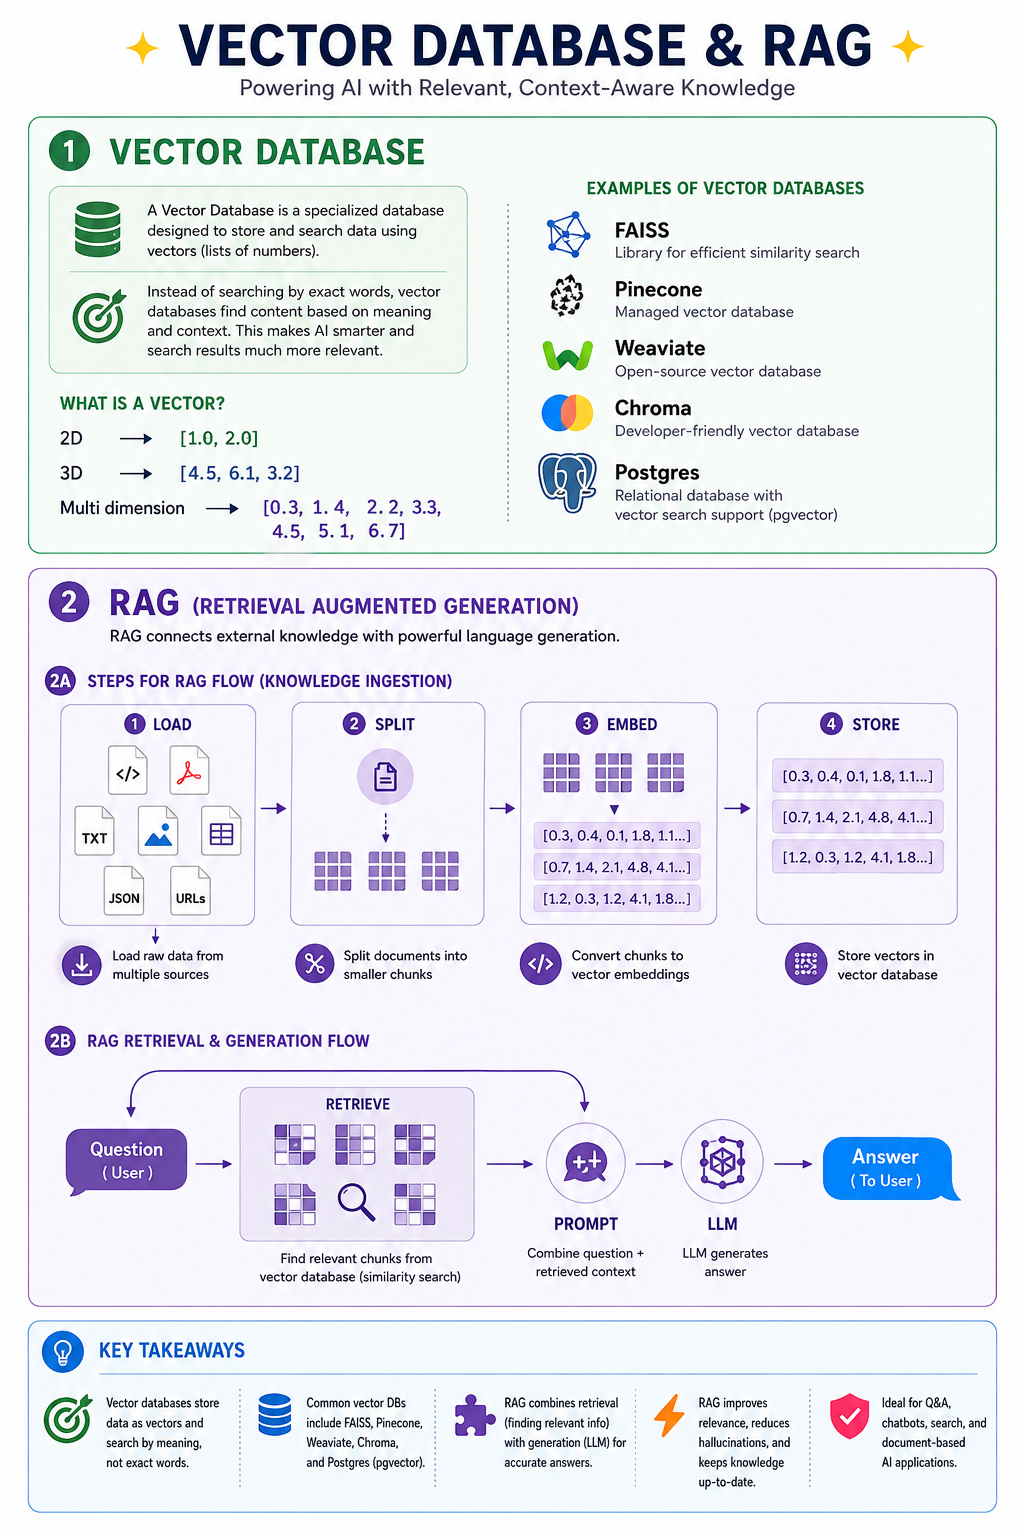

### For understand why RAG , in below the llm not able to answer to a specific content which is not general like bank history , company Transactions etc... , so we use 

Loading Document

In [7]:
from langchain_community.document_loaders import TextLoader

file_path = r"./Additional files/10_vijay_Small_RAG_Content.txt"

loader = TextLoader(file_path, encoding="utf-8")

documents = loader.load()

print(documents)

[Document(metadata={'source': './Additional files/10_vijay_Small_RAG_Content.txt'}, page_content='VIJAY (ACTOR) — CONDENSED RAG CONTENT\n\nIDENTITY\n- “Vijay (actor)” redirects here. For other people named Vijay, see Vijay (name).\n- In this Tamil name, there is no surname or family name. The name Chandrasekaran is a patronym, and the person should be referred to by their given name, Joseph Vijay.\n- Full name: C. Joseph Vijay\n- Born: Chandrasekaran Joseph Vijay\n- Date of birth: 22 June 1974 (age 52)\n- Place of birth: Madras, India\n- Caption: Vijay in 2026\n- Occupation: Politician; actor\n- Party: Tamilaga Vettri Kazhagam\n\nPOLITICAL OFFICES\n- 9th Chief Minister of Tamil Nadu\n  - Status: Incumbent\n  - Assumed office: 10 May 2026\n  - Governor: Rajendra Arlekar (additional charge)\n  - Preceded by: M. K. Stalin\n- Member of the Tamil Nadu Legislative Assembly\n  - Status: Incumbent\n  - Assumed office: 4 May 2026\n  - Preceded by: R. D. Shekar\n  - Constituency: Perambur\n- Pre

Splitting Text 

In [8]:
from langchain_text_splitters import RecursiveCharacterTextSplitter
from pprint import pprint

text_splitter=RecursiveCharacterTextSplitter(chunk_size=300,chunk_overlap=30)


chunks=text_splitter.split_documents(documents)

print(len(chunks))
pprint(chunks)

94
[Document(metadata={'source': './Additional files/10_vijay_Small_RAG_Content.txt'}, page_content='VIJAY (ACTOR) — CONDENSED RAG CONTENT'),
 Document(metadata={'source': './Additional files/10_vijay_Small_RAG_Content.txt'}, page_content='IDENTITY\n- “Vijay (actor)” redirects here. For other people named Vijay, see Vijay (name).\n- In this Tamil name, there is no surname or family name. The name Chandrasekaran is a patronym, and the person should be referred to by their given name, Joseph Vijay.\n- Full name: C. Joseph Vijay'),
 Document(metadata={'source': './Additional files/10_vijay_Small_RAG_Content.txt'}, page_content='- Full name: C. Joseph Vijay\n- Born: Chandrasekaran Joseph Vijay\n- Date of birth: 22 June 1974 (age 52)\n- Place of birth: Madras, India\n- Caption: Vijay in 2026\n- Occupation: Politician; actor\n- Party: Tamilaga Vettri Kazhagam'),
 Document(metadata={'source': './Additional files/10_vijay_Small_RAG_Content.txt'}, page_content='POLITICAL OFFICES\n- 9th Chief Mi

Embedding the chunks


In [9]:
from langchain_huggingface import HuggingFaceEmbeddings


embeddings = HuggingFaceEmbeddings(
    model_name="sentence-transformers/all-MiniLM-L6-v2"
)

chunk_text = [document.page_content for document in chunks]

vector_embed = embeddings.embed_documents(chunk_text)

print(len(vector_embed))
print(len(vector_embed[0]))

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

94
384


Storing it in vector DB

In [10]:
from langchain_community.vectorstores import FAISS
db =FAISS.from_documents(chunks,embeddings)
results = db.similarity_search("when vijey come to politics")
print(results)

[Document(id='7acc3ef1-dbd7-4671-82b9-6abd7e2abde8', metadata={'source': './Additional files/10_vijay_Small_RAG_Content.txt'}, page_content='- On 30 January 2026, Vijay said his role models include M. G. Ramachandran, J. Jayalalithaa and M. Karunanidhi, in his first NDTV interview since entering politics.[151]'), Document(id='c739ee5b-9b13-44e2-bf6c-bba9bc6675bf', metadata={'source': './Additional files/10_vijay_Small_RAG_Content.txt'}, page_content='In February 2024, Vijay announced his retirement from cinema and formal entry into politics. He launched TVK as a secular and egalitarian alternative to the established Dravidian parties. TVK secured 108 seats in the 2026 Tamil Nadu Legislative Assembly election, becoming the single-largest party'), Document(id='32d01bc9-1df9-47bc-82c4-1637567e866a', metadata={'source': './Additional files/10_vijay_Small_RAG_Content.txt'}, page_content="- Villu and Vettaikaaran (2009) were average domestic successes but more successful overseas.[56][57][58

##### here the this vector store is not Runnable so to change this to runnable use below method

###### without Runnable we wont invoke it , in above instead of invoke we use similarity search

Make vectorstore to runnable

In [11]:
retriever=db.as_retriever()  # by using this we can change this to runnable

print(retriever.invoke("when vijey come to politics"))

[Document(id='7acc3ef1-dbd7-4671-82b9-6abd7e2abde8', metadata={'source': './Additional files/10_vijay_Small_RAG_Content.txt'}, page_content='- On 30 January 2026, Vijay said his role models include M. G. Ramachandran, J. Jayalalithaa and M. Karunanidhi, in his first NDTV interview since entering politics.[151]'), Document(id='c739ee5b-9b13-44e2-bf6c-bba9bc6675bf', metadata={'source': './Additional files/10_vijay_Small_RAG_Content.txt'}, page_content='In February 2024, Vijay announced his retirement from cinema and formal entry into politics. He launched TVK as a secular and egalitarian alternative to the established Dravidian parties. TVK secured 108 seats in the 2026 Tamil Nadu Legislative Assembly election, becoming the single-largest party'), Document(id='32d01bc9-1df9-47bc-82c4-1637567e866a', metadata={'source': './Additional files/10_vijay_Small_RAG_Content.txt'}, page_content="- Villu and Vettaikaaran (2009) were average domestic successes but more successful overseas.[56][57][58

Get response from LLM

In [12]:
from langchain_core.runnables import RunnablePassthrough

# Create RAG chain using LCEL
def format_docs(docs):
    return "\n\n".join(doc.page_content for doc in docs)

prompt_template = ChatPromptTemplate.from_template("""
Use the following context to answer the question:
Context: {context}
Question: {question}

Answer:""")

chain = {"context": retriever | format_docs, "question": RunnablePassthrough()} | prompt_template | llm | StrOutputParser()

print(chain.invoke("What post vijey in politics now?"))



Vijay is currently serving as the **President of the Tamilaga Vettri Kazhagam (TVK)**, a post he has held since assuming office on 2 February 2024.
